In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [26]:
from typing import Literal
from pydantic import BaseModel

In [2]:
load_dotenv()

True

NORMAL LLM

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

STATE

In [42]:
from typing import TypedDict

class FinancialState(TypedDict):
    query : str
    response : str

    company: str
    ticker: str

    market_data:dict
    route : str
    

PYDANTIC MODEL

In [30]:
class RouteDecision(BaseModel):
    route: Literal["market_agent"]

In [43]:
class CompanyExtraction(BaseModel):
    company: str

STRUCTURE MODEL

In [31]:
router_llm = llm.with_structured_output(RouteDecision)

In [44]:
extractor_llm = llm.with_structured_output(
    CompanyExtraction
)

TOOLS TO BE USED

In [36]:
import yfinance as yf

In [37]:
def get_stock_data(symbol: str):

    stock = yf.Ticker(symbol)

    info = stock.info

    return {
        "company": info.get("longName"),
        "price": info.get("currentPrice"),
        "market_cap": info.get("marketCap"),
        "pe_ratio": info.get("trailingPE"),
        "sector": info.get("sector"),
    }

NODE FUNCTION

In [32]:
def supervisor_agent(state: FinancialState):
    query = state["query"]

    prompt = f"""
        You are a routing agent.

        Choose which agent should answer the user's query.

        Available agents:

        market_agent

        Return ONLY the agent name.

        User Query:
        {query}
    """
    decision = router_llm.invoke(prompt)
    print(decision)
    return {
        "route": decision.route
    }

In [17]:
def market_agent(state: FinancialState):

    query = state["query"]

    prompt = f"""
        You are a financial analyst.

        Answer the following question.

        Question:
        {query}
    """

    answer = llm.invoke(prompt)

    return {
        "response": answer.content
    }

In [20]:
def router(state: FinancialState):
    return state["route"]

In [45]:
def entity_extractor_agent(state: FinancialState):

    query = state["query"]
    prompt = f"""
        You are a financial entity extraction agent.

        Extract ONLY the company name mentioned.

        Examples

        Input:
        Should I invest in Apple?

        Output:
        Apple

        Input:
        Analyze Microsoft stock.

        Output:
        Microsoft

        Input:
        Tell me about Tesla.

        Output:
        Tesla

        User Query:

        {query}
    """

    result = extractor_llm.invoke(prompt)
    print(f"\nCompany: {result.company}")
    return {
        "company": result.company
    }

In [53]:
TICKER_MAP = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Google": "GOOGL",
    "Alphabet": "GOOGL",
    "Amazon": "AMZN",
    "Tesla": "TSLA",
    "Meta": "META",
    "NVIDIA": "NVDA",
    "Netflix": "NFLX",
    "Intel": "INTC",
    "AMD": "AMD",

    "Reliance": "RELIANCE.NS",
    "TCS": "TCS.NS",
    "Infosys": "INFY.NS",
    "Wipro": "WIPRO.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS",
}

In [54]:
def ticker_resolver_agent(state: FinancialState):

    company = state["company"]

    ticker = TICKER_MAP.get(company)

    if ticker is None:
        ticker = company

    print(f"\nTicker: {ticker}")

    return {
        "ticker": ticker
    }

In [55]:
builder = StateGraph(FinancialState)

#nodes
builder.add_node("supervisor", supervisor_agent)
builder.add_node("market_agent", market_agent)
builder.add_node("entity_extractor",entity_extractor_agent)
builder.add_node("ticker_resolver",ticker_resolver_agent)

#edges
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    router,
    {
        "market_agent": "entity_extractor"
    }
)
builder.add_edge("entity_extractor","ticker_resolver")
builder.add_edge("ticker_resolver","market_agent")
builder.add_edge("market_agent", END)

graph = builder.compile()

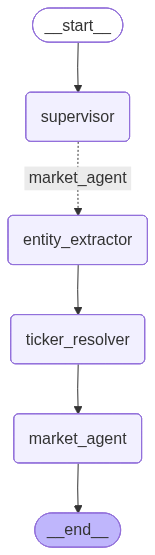

In [56]:
graph

In [57]:
query = "Analyze NVIDIA"
result = graph.invoke({
    "query": query,
    "route": "",
    "company": "",
    "ticker": "",
    "market_data": {},
    "response": ""
})

route='market_agent'

Company: NVIDIA

Ticker: NVDA


In [58]:
result

{'query': 'Analyze NVIDIA',
 'response': "As a financial analyst, here's an analysis of NVIDIA Corporation (NVDA), focusing on its business, financial health, competitive landscape, growth drivers, risks, and valuation considerations.\n\n---\n\n## NVIDIA Corporation (NVDA) - Financial Analyst Report\n\n**Date:** October 26, 2023 (or current date of analysis)\n\n**Ticker:** NVDA\n**Exchange:** NASDAQ\n\n### 1. Executive Summary\n\nNVIDIA Corporation is a leading designer of graphics processing units (GPUs) and system-on-a-chip (SoC) units. The company has successfully transitioned from primarily a gaming GPU provider to a dominant force in the artificial intelligence (AI) and data center markets. Its proprietary CUDA software platform creates a significant competitive moat. While exhibiting exceptional growth, particularly in its Data Center segment, NVIDIA trades at a premium valuation reflecting high future growth expectations and its pivotal role in the ongoing AI revolution. Investo